# BHARTIARTL Individual Analysis

Loads the raw BHARTIARTL OHLCV data, then plots candles, volume, drawdown, and daily returns.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

In [2]:
TICKER = "BHARTIARTL.NS"

candidate_paths = [
    Path("..").resolve() / "raw" / f"{TICKER}.csv",
    Path("large-cap") / "stock_analysis" / "data" / "raw" / f"{TICKER}.csv",
]
RAW_DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if RAW_DATA_PATH is None:
    raise FileNotFoundError(f"Could not find raw data for {TICKER}")

df = pd.read_csv(RAW_DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")

price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
df["daily_return"] = df[price_col].pct_change()
df["running_max"] = df[price_col].cummax()
df["drawdown"] = df[price_col] / df["running_max"] - 1

df.head()

,Open,High,Low,Close,Adj Close,Volume,daily_return,running_max,drawdown
Date,,,,,,,,,
2023-08-28,874.05,875.75,865.85,870.35,847.68,3094455,NaN,847.68,0.00
2023-08-29,870.00,870.00,848.50,855.20,832.93,14064286,-0.02,847.68,-0.02
2023-08-30,859.85,862.60,856.45,857.75,835.41,3261665,0.00,847.68,-0.01
2023-08-31,855.50,859.50,847.05,856.40,834.10,12528190,-0.00,847.68,-0.02
2023-09-01,853.15,867.55,852.75,865.95,843.40,4427899,0.01,847.68,-0.01


In [3]:
df[["Open", "High", "Low", "Close", "Adj Close", "Volume", "daily_return", "drawdown"]].tail()

,Open,High,Low,Close,Adj Close,Volume,daily_return,drawdown
Date,,,,,,,,
2026-08-24,"1,950.00","1,952.50","1,932.50","1,935.00","1,935.00",2277098,-0.01,-0.09
2026-08-25,"1,926.00","1,947.00","1,923.40","1,947.00","1,947.00",3820206,0.01,-0.09
2026-08-26,"1,933.50","1,942.90","1,902.10","1,902.10","1,902.10",4552921,-0.02,-0.11
2026-08-27,"1,915.00","1,915.00","1,878.30","1,878.30","1,878.30",8757645,-0.01,-0.12
2026-08-28,"1,875.70","1,894.30","1,867.60","1,882.40","1,882.40",6103006,0.00,-0.12


## Candlestick Chart

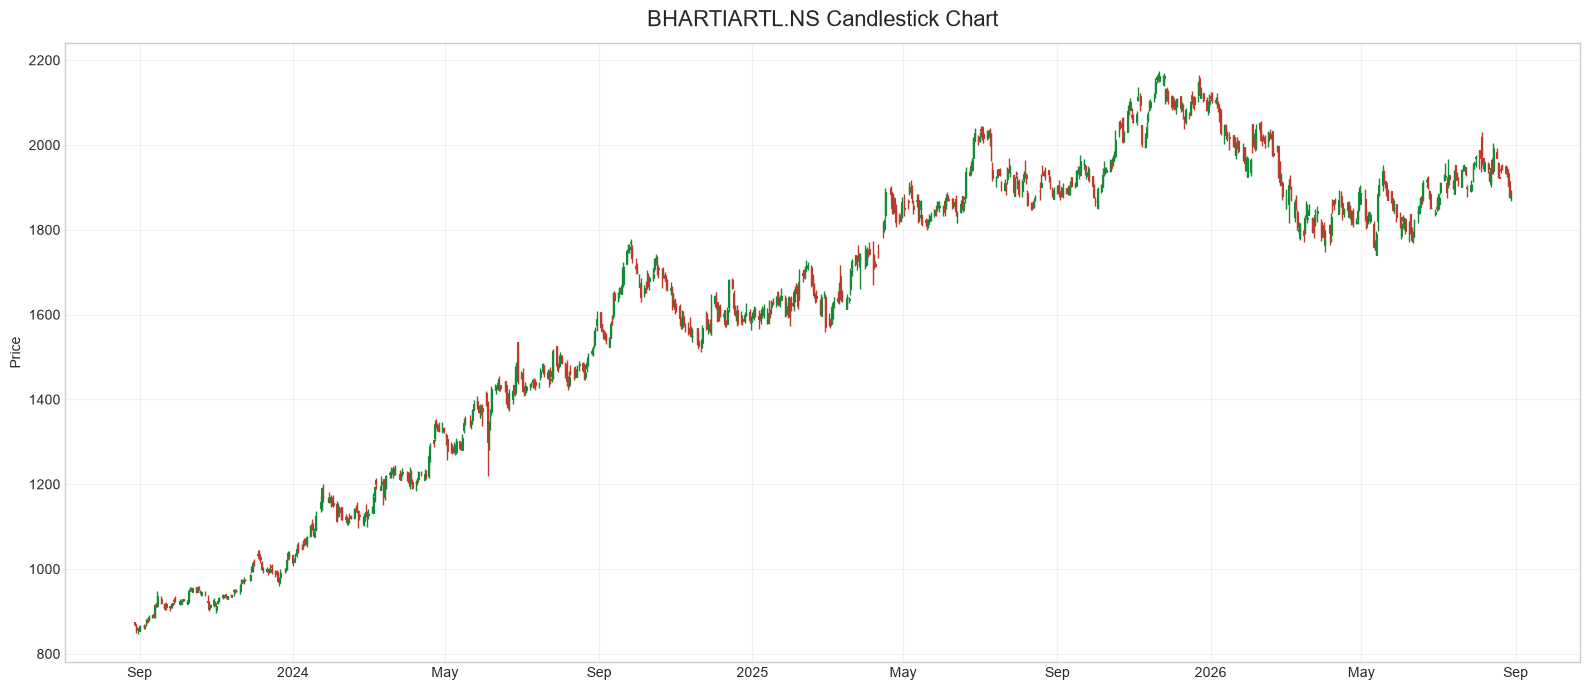

In [4]:
def plot_candles(data, title):
    plot_data = data.reset_index().copy()
    plot_data["date_num"] = mdates.date2num(plot_data["Date"])

    fig, ax = plt.subplots(figsize=(16, 7))
    candle_width = 0.7

    for row in plot_data.itertuples(index=False):
        color = "#138a36" if row.Close >= row.Open else "#c0392b"
        lower = min(row.Open, row.Close)
        height = abs(row.Close - row.Open)

        ax.vlines(row.date_num, row.Low, row.High, color=color, linewidth=1)
        ax.add_patch(
            Rectangle(
                (row.date_num - candle_width / 2, lower),
                candle_width,
                height if height > 0 else 0.01,
                facecolor=color,
                edgecolor=color,
                linewidth=0.8,
            )
        )

    ax.set_title(title, fontsize=16, pad=12)
    ax.set_ylabel("Price")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig, ax

plot_candles(df, f"{TICKER} Candlestick Chart");

## Volume

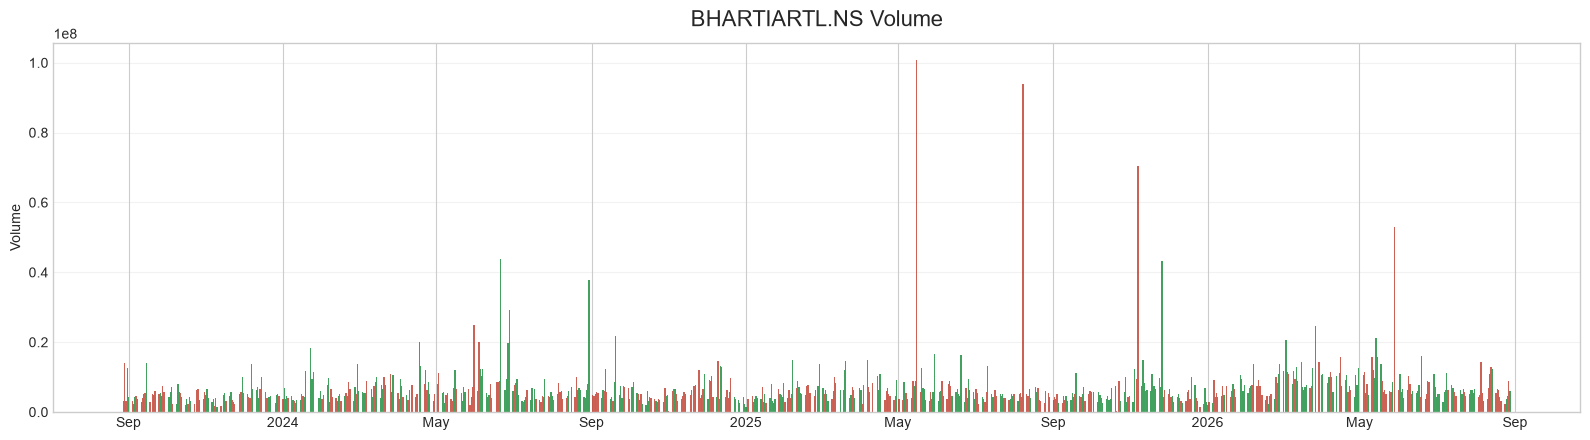

In [5]:
volume_colors = df.apply(lambda row: "#138a36" if row["Close"] >= row["Open"] else "#c0392b", axis=1)

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.bar(df.index, df["Volume"], color=volume_colors, width=1.0, alpha=0.8)
ax.set_title(f"{TICKER} Volume", fontsize=16, pad=12)
ax.set_ylabel("Volume")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()

## Drawdown and Daily Return

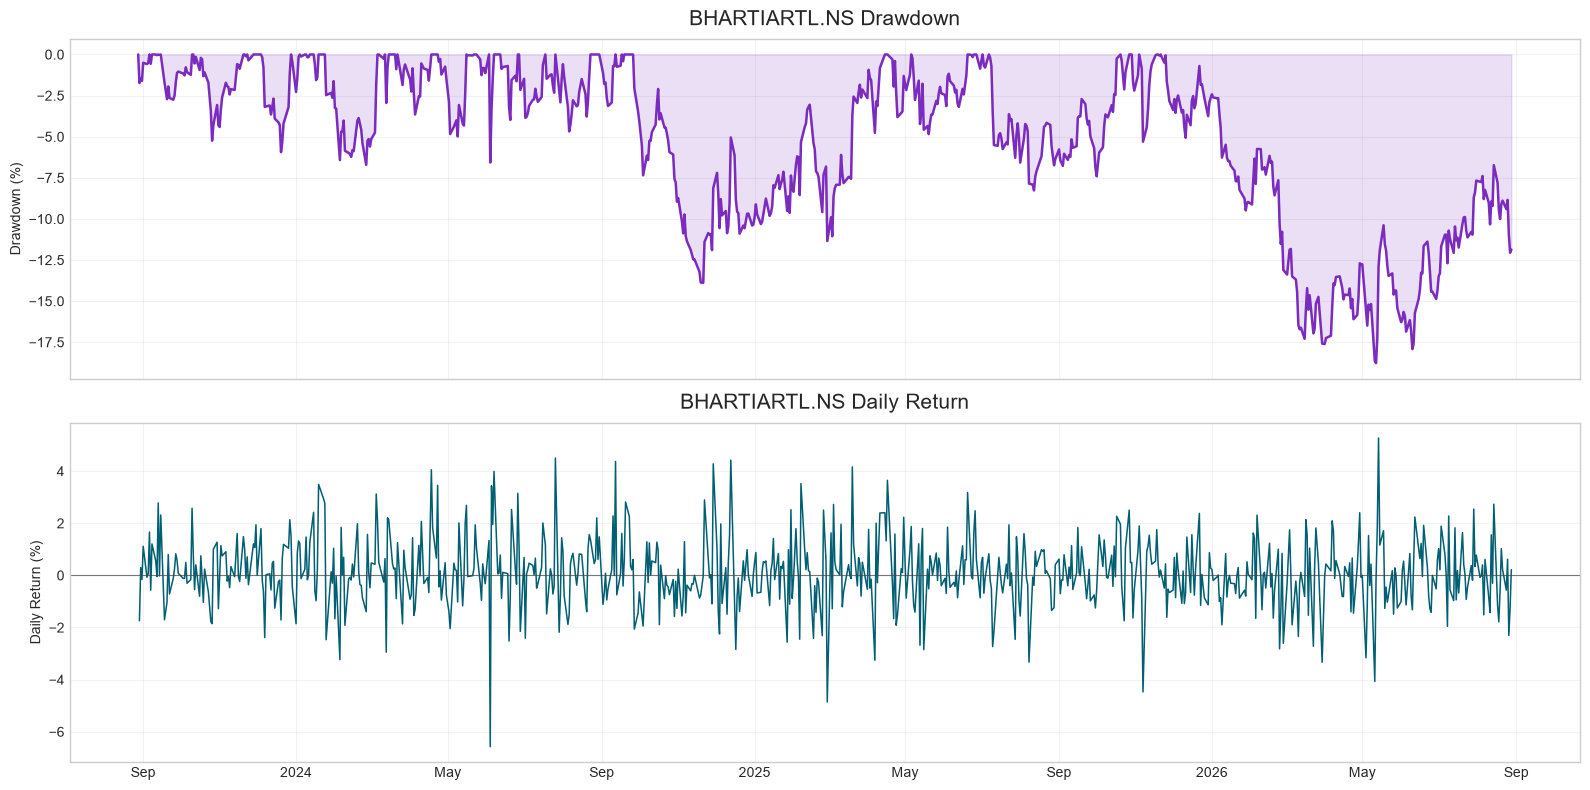

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df["drawdown"] * 100, color="#7b2cbf", linewidth=1.8)
axes[0].fill_between(df.index, df["drawdown"] * 100, 0, color="#7b2cbf", alpha=0.15)
axes[0].set_title(f"{TICKER} Drawdown", fontsize=15, pad=10)
axes[0].set_ylabel("Drawdown (%)")
axes[0].grid(True, alpha=0.25)

axes[1].plot(df.index, df["daily_return"] * 100, color="#005f73", linewidth=1.1)
axes[1].axhline(0, color="#444444", linewidth=0.8, alpha=0.7)
axes[1].set_title(f"{TICKER} Daily Return", fontsize=15, pad=10)
axes[1].set_ylabel("Daily Return (%)")
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
axes[1].grid(True, alpha=0.25)

fig.tight_layout()

In [7]:
summary = pd.Series(
    {
        "start_date": df.index.min().date(),
        "end_date": df.index.max().date(),
        "last_close": df["Close"].iloc[-1],
        "last_volume": df["Volume"].iloc[-1],
        "total_return_pct": (df[price_col].iloc[-1] / df[price_col].iloc[0] - 1) * 100,
        "max_drawdown_pct": df["drawdown"].min() * 100,
        "avg_daily_return_pct": df["daily_return"].mean() * 100,
    }
)

summary

start_date              2023-08-28
end_date                2026-08-28
last_close                1,882.40
last_volume                6103006
total_return_pct            122.06
max_drawdown_pct            -18.77
avg_daily_return_pct          0.12
dtype: object